<a href="https://colab.research.google.com/github/paula-33/Bootcamp-UniSENAI---Ciencia-de-dados/blob/main/Notebook_02_Pre_processamento_e_escolha_do_modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Padronizando os dados

Normalização ou padronização (MinMax, Z-score) se necessário.



In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, hamming_loss
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Pré-processamento dos dados

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bootcamp DS/Projeto Final/df_final.csv')
df = df.drop('tipo_do_aço_A400', axis=1)
df = df.rename(columns={'tipo_do_aço_A300': 'flag_aco_A300'})

# 2. Separação de features (X) e rótulos (y) multi-label
categorical_cols = ['falha_1', 'falha_2', 'falha_3', 'falha_4', 'falha_5', 'falha_6', 'falha_outros']

y = df[categorical_cols]
features = df.drop(columns=categorical_cols)

In [ ]:
# 3. Estratificação multi-label - Criação de rótulo combinado para estratificação multi-label
y_str = y.astype(int).astype(str).agg('_'.join, axis=1)


# 4. Divisão estratificada: treino (70%) e temp (30%)
sss1 = StratifiedShuffleSplit(n_splits=1, train_size=0.7, test_size=0.3, random_state=42)
train_idx, temp_idx = next(sss1.split(features, y_str))
X_train, y_train_str = features.iloc[train_idx], y_str.iloc[train_idx]
X_temp,  y_temp_str = features.iloc[temp_idx], y_str.iloc[temp_idx]
y_temp = y.iloc[temp_idx]

# 5. Divisão estratificada sobre temp: validação (20%) e teste (10%)
# Proporção: validação = 20/30 ≈ 0.666, teste = 0.333
sss2 = StratifiedShuffleSplit(n_splits=1, train_size=2/3, test_size=1/3, random_state=42)
val_idx, test_idx = next(sss2.split(X_temp, y_temp_str))
X_val, y_val   = X_temp.iloc[val_idx], y.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y.iloc[test_idx]

# 6. Normalização Min-Max (fit só no treino, transform em todos)
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns
scaler = MinMaxScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features]   = scaler.transform(X_val[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

# 7. Aplicação de SMOTE no conjunto de treino
 # X_train_res recriado com as colunas originais de features.
 # y_train_res recriado como um DataFrame multi-hot.

smote = SMOTE(random_state=42)
X_train_res, y_train_res_str = smote.fit_resample(X_train, y_train_str)

# Reconstrução de y_train_res em formato multi-hot (DataFrame)
y_train_res = pd.DataFrame(
    y_train_res_str.str.split('_', expand=True).astype(int).values,
    columns=categorical_cols
)

# Reconstrução de X_train_res com colunas originais
X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)

# 8. Avaliação de tamanhos e balanceamento
balance_before = y.iloc[train_idx].sum().rename('antes')
balance_after  = y_train_res.sum().rename('depois')
balance_df = pd.concat([balance_before, balance_after], axis=1)


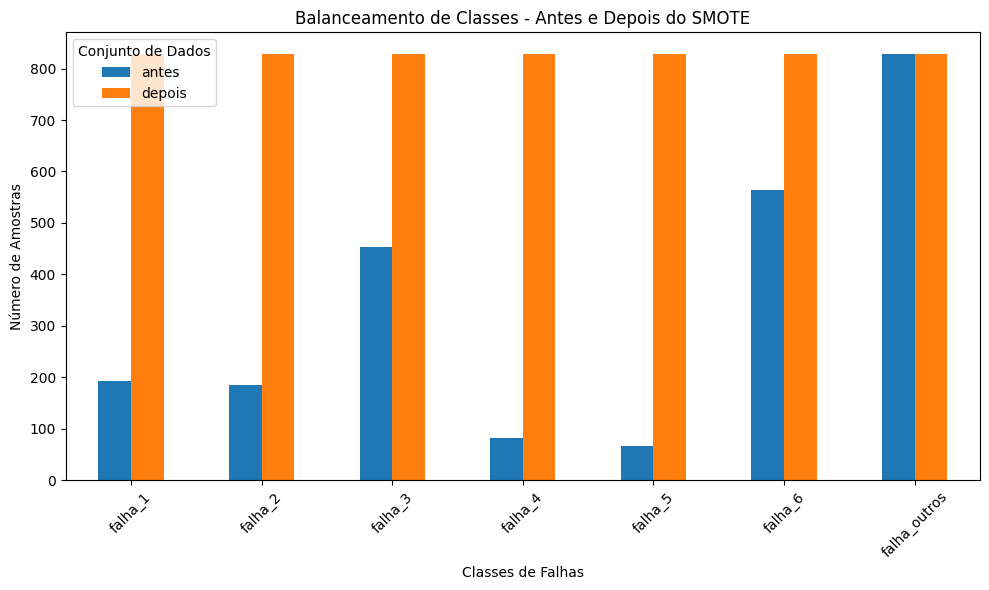

In [ ]:
# Criando o gráfico
balance_df.plot(kind='bar', figsize=(10, 6))
plt.title('Balanceamento de Classes - Antes e Depois do SMOTE')
plt.xlabel('Classes de Falhas')
plt.ylabel('Número de Amostras')
plt.xticks(rotation=45)
plt.legend(title='Conjunto de Dados')
plt.tight_layout()
plt.show()


In [ ]:
 def failure_summary(y_df):
    """
    Generates a summary table with failure counts and percentages.

    Args:
      y_df: A pandas DataFrame where columns represent failure types (0 or 1).

    Returns:
      A pandas DataFrame with failure counts and percentages.
    """
    summary = []
    for col in y_df.columns:
        total = len(y_df)
        count_1 = y_df[col].sum()
        count_0 = total - count_1
        percent_1 = (count_1 / total) * 100
        percent_0 = (count_0 / total) * 100
        summary.append([col, count_1, f"{percent_1:.2f}%", count_0, f"{percent_0:.2f}%"])

    return pd.DataFrame(summary, columns=["Falha", "Qtd 1", "% 1", "Qtd 0", "% 0"])

# Example usage for the original data (before SMOTE)
summary_before_smote = failure_summary(y)
print(" (Antes SMOTE):")
print(summary_before_smote)
print("\n")

# Example usage for the data after SMOTE
summary_after_smote = failure_summary(y_train_res)
print(" (Depois SMOTE):")
summary_after_smote


 (Antes SMOTE):
          Falha  Qtd 1     % 1  Qtd 0     % 0
0       falha_1    275   8.11%   3115  91.89%
1       falha_2    264   7.79%   3126  92.21%
2       falha_3    649  19.14%   2741  80.86%
3       falha_4    116   3.42%   3274  96.58%
4       falha_5     96   2.83%   3294  97.17%
5       falha_6    806  23.78%   2584  76.22%
6  falha_outros   1184  34.93%   2206  65.07%


 (Depois SMOTE):


,Falha,Qtd 1,% 1,Qtd 0,% 0
0,falha_1,829,14.29%,4974,85.71%
1,falha_2,829,14.29%,4974,85.71%
2,falha_3,829,14.29%,4974,85.71%
3,falha_4,829,14.29%,4974,85.71%
4,falha_5,829,14.29%,4974,85.71%
5,falha_6,829,14.29%,4974,85.71%
6,falha_outros,829,14.29%,4974,85.71%


In [ ]:

print("=== Tamanhos dos Conjuntos ===")
print(f"Train original: {X_train.shape[0]} amostras")
print(f"Train após SMOTE: {X_train_res.shape[0]} amostras")
print("\n=== Balanceamento Antes vs Depois ===")
print(balance_df)

=== Tamanhos dos Conjuntos ===
Train original: 2373 amostras
Train após SMOTE: 5803 amostras

=== Balanceamento Antes vs Depois ===
              antes  depois
falha_1         193     829
falha_2         185     829
falha_3         454     829
falha_4          81     829
falha_5          67     829
falha_6         564     829
falha_outros    829     829


## Comentários:

Ao longo do pipeline, implementamos sistematicamente as boas práticas de preparação de dados para cenários industriais de classificação multi-label, com foco na confiabilidade, reprodutibilidade e interpretabilidade:

## Pré-processamento inicial
- Remoção de colunas não relevantes e renomeação para clareza asseguraram um dataset limpo e bem documentado.
- A separação explícita entre features e rótulos (sete flags de falha) trouxe transparência à estrutura de X e y.

## Estratificação multi-label
- Ao concatenar as flags em um único rótulo combinado, garantimos que a divisão refletisse a distribuição conjunta das falhas, mantendo a representatividade de cada padrão de defeito nos subsets de treino, validação e teste.

## Divisão 70%/20%/10% estratificada
- Dois estágios de `StratifiedShuffleSplit` definiram corretamente 70% para treino e, depois, 20% validação e 10% teste, todos estratificados pelo rótulo combinado.
- Isso evita vieses de classe e assegura avaliação realista de performance em dados não vistos.

## Normalização Min-Max sem vazamento (data leakage)
- O ajuste (`fit`) do scaler foi restrito ao conjunto de treino, e o mesmo parâmetro foi aplicado (`transform`) em validação e teste.
- Assim, preservamos a integridade dos dados de avaliação e garantimos que o modelo não “visse” informação futura.

## Balanceamento com SMOTE
- Aplicamos SMOTE apenas no treino, gerando instâncias sintéticas por interpolação, o que amplia a variedade de exemplos minoritários sem simples replicação.
- A reconstrução dos rótulos multi-hot permitiu recuperar o formato original, pronto para alimentar o modelo.
- **Observação**: como usamos SMOTE sobre o rótulo combinado, podem surgir combinações de falhas inexistentes originalmente; em cenários muito sensíveis, explorar variantes de SMOTE multi-label mais especializadas pode ser recomendado.

## Validação do balanceamento
- A inspeção das contagens antes e depois de SMOTE confirmou o sucesso no nivelamento das classes, preparando um treino mais robusto.

## Conclusão geral
O pipeline constrói um fluxo sólido que evita armadilhas comuns — como data leakage e má representação de classes — e fornece um conjunto de treino equilibrado e processado de forma consistente. Isso garante que modelos subsequentes sejam treinados em dados confiáveis, interpretáveis por engenheiros de processo e prontos para avaliação legítima em produção.


# Criação do modelo

In [ ]:
# --- 1. Definição dos modelos multi-output ---
models = {
    'Random Forest': MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42)),
    'XGBoost':       MultiOutputClassifier(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    'MLP Neural Net':MultiOutputClassifier(MLPClassifier(hidden_layer_sizes=(100,100), max_iter=200, random_state=42))
}

# --- 2. Treinamento e avaliação em validação ---
reports = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = pd.DataFrame(model.predict(X_val), columns=categorical_cols, index=y_val.index)
    report = classification_report(y_val, y_pred, zero_division=0, output_dict=True)
    h_loss = hamming_loss(y_val, y_pred)
    reports[name] = {'report': report, 'hamming_loss': h_loss}


In [ ]:
# --- 1. Gerar resumo dos resultados ---
results_summary = []
for name, res in reports.items():
    avg_f1 = res['report']['weighted avg']['f1-score']
    h_loss = res['hamming_loss']
    results_summary.append({'Model': name, 'Weighted F1 (val)': avg_f1, 'Hamming Loss': h_loss})

# --- 2. Criar DataFrame ---
result_moledo = pd.DataFrame(results_summary).set_index('Model')


In [ ]:

# --- 3. Exibir tabela ---
print("Comparativo de Modelos (Validação):")
print(result_moledo)

Comparativo de Modelos (Validação):
                Weighted F1 (val)  Hamming Loss
Model                                          
Random Forest            0.144945      0.194690
XGBoost                  0.157553      0.209018
MLP Neural Net           0.113586      0.207122


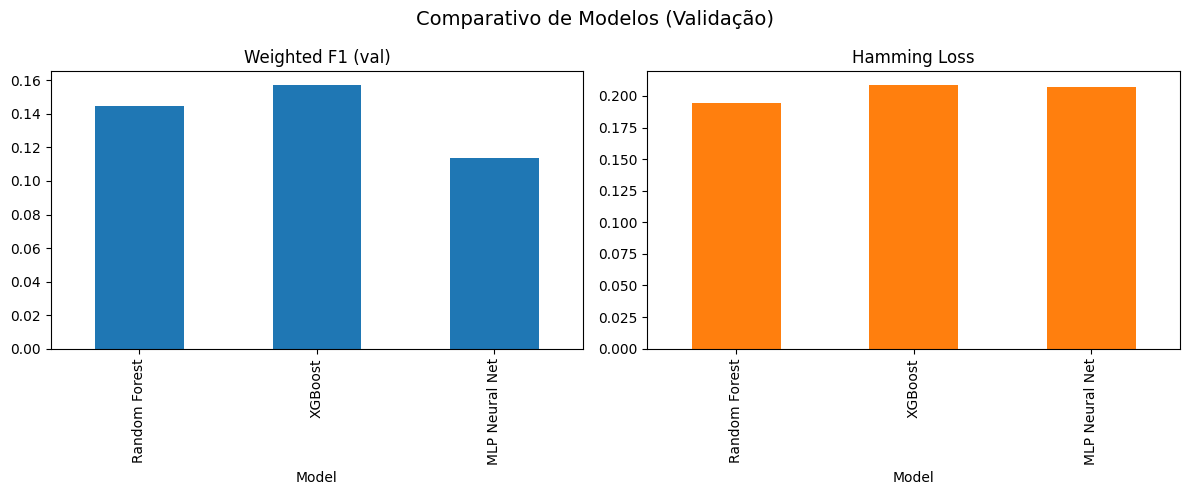

In [ ]:
# --- 4. Exibir gráficos ---
result_moledo.plot(kind='bar', subplots=True, layout=(1, 2), figsize=(12, 5), legend=False, title=['Weighted F1 (val)', 'Hamming Loss'])
plt.suptitle("Comparativo de Modelos (Validação)", fontsize=14)
plt.tight_layout()
plt.show()

Comentários:

 **Escolha: XGBoost**

- **Melhor F1 ponderado (0.158):** captura mais fielmente o *trade-off* entre precisão e recall nas múltiplas labels, o que é fundamental em um cenário de defeitos industriais multi-rótulo.

- **Hamming Loss** ligeiramente mais alto (0.208 vs. 0.195 do RF), mas a diferença é pequena frente ao ganho no F1 global. Em problemas multi-label, priorizamos uma métrica que reflita bem tanto falsos positivos quanto falsos negativos ponderados pela frequência de cada classe.

- **Vantagens práticas:** XGBoost costuma convergir mais rápido e oferece ferramentas nativas de interpretação (*feature importance*), facilitando o entendimento pelos engenheiros de processo.


## Resumo das Etapas Realizadas no Notebook:

1.  **Importação de Bibliotecas:** Importação das bibliotecas necessárias para manipulação de dados, modelagem e visualização.
2.  **Carregamento e Pré-processamento Inicial dos Dados:**
    *   Leitura do arquivo CSV `df_final.csv`.
    *   Remoção da coluna 'tipo_do_aço_A400'.
    *   Renomeação da coluna 'tipo_do_aço_A300' para 'flag_aco_A300'.
3.  **Separação de Features e Rótulos Multi-label:** Definição das colunas de falha como rótulos (`y`) e o restante como features (`X`).
4.  **Estratificação Multi-label:** Criação de um rótulo combinado para garantir a estratificação adequada na divisão dos dados.
5.  **Divisão Estratificada dos Dados:** Divisão do dataset em treino (70%), validação (20%) e teste (10%) usando `StratifiedShuffleSplit` para manter a distribuição das classes de falha.
6.  **Normalização Min-Max:** Aplicação do `MinMaxScaler` nas features numéricas, ajustando apenas no conjunto de treino para evitar vazamento de dados.
7.  **Balanceamento com SMOTE:** Aplicação do SMOTE no conjunto de treino para lidar com o desbalanceamento das classes de falha.
8.  **Avaliação do Balanceamento:** Verificação do balanceamento das classes antes e depois do SMOTE, incluindo a geração de um gráfico comparativo.
9.  **Criação e Treinamento de Modelos Multi-output:**
    *   Definição de três modelos multi-output: Random Forest, XGBoost e MLP Neural Network.
    *   Treinamento dos modelos com os dados de treino balanceados.
10. **Avaliação dos Modelos:**
    *   Realização de previsões nos dados de validação.
    *   Geração de relatórios de classificação e cálculo do Hamming Loss para cada modelo.
11. **Comparativo de Modelos:**
    *   Criação de um resumo comparando o Weighted F1-score e o Hamming Loss dos modelos na validação.
    *   Exibição da tabela e gráficos comparativos dos resultados.
12. **Conclusão e Escolha do Modelo:** Análise dos resultados para escolher o melhor modelo (XGBoost) com base nas métricas de avaliação.